# Cell 1: Problem Statement and Imports

## Lending Club Loan Data Analysis
**Objective:** Build a deep learning model to predict the chance of loan default using historical data from 2007 to 2015.

### Dataset Definition:
- **credit.policy**: 1 if criteria met, 0 otherwise.
- **purpose**: The category of the loan.
- **fico**: The FICO credit score of the borrower.
- **not.fully.paid**: The target variable (1 = default, 0 = paid).

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

C:\Users\richa\src\repos\fullstack\fs-aim-2507\assignments\unit4_deep_learning_with_tensorflow_and_keras\Unit4_CourseEndProject\LendingClubLoanDataAnalysis\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


# Cell 2: Load and Inspect Data

In [3]:
# Load the dataset
df = pd.read_csv('./data/loan_data.csv')

# Initial inspection
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB
None


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


## Cell 3: Task 1 - Feature Transformation

### 1. Feature Transformation
We transform the categorical column 'purpose' into numerical values using One-Hot Encoding.
We use `drop_first=True` to avoid the dummy variable trap.

In [4]:
final_data = pd.get_dummies(df, columns=['purpose'], drop_first=True)
final_data.head()


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,False,True,False,False,False,False
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,True,False,False,False,False,False
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,False,True,False,False,False,False
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,False,True,False,False,False,False
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,True,False,False,False,False,False


## Cell 4: Task 2 - Exploratory Data Analysis (EDA)

### 1. Feature Transformation
We transform the categorical column 'purpose' into numerical values using One-Hot Encoding.
We use `drop_first=True` to avoid the dummy variable trap.

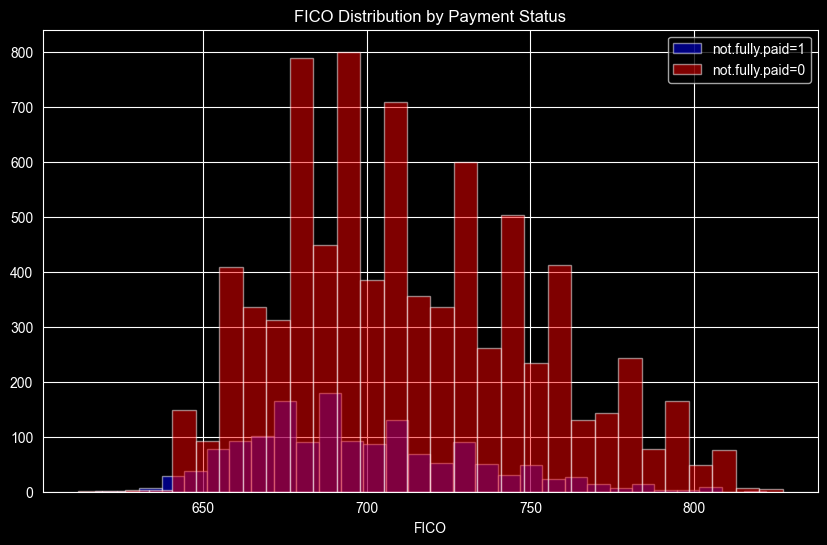

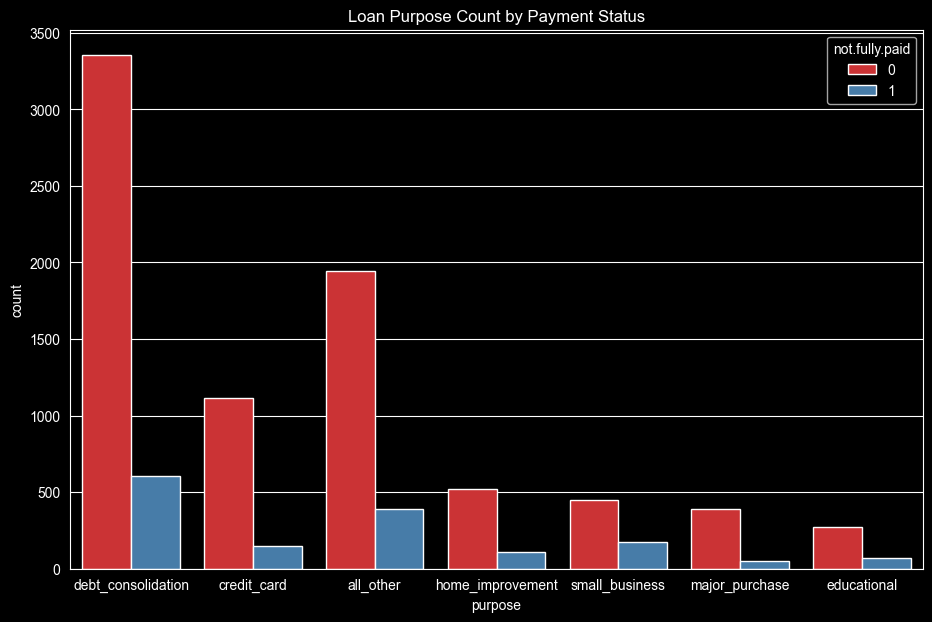

In [6]:

plt.figure(figsize=(10,6))
df[df['not.fully.paid']==1]['fico'].hist(alpha=0.5, color='blue', bins=30, label='not.fully.paid=1')
df[df['not.fully.paid']==0]['fico'].hist(alpha=0.5, color='red', bins=30, label='not.fully.paid=0')
plt.legend()
plt.xlabel('FICO')
plt.title('FICO Distribution by Payment Status')
plt.show()

plt.figure(figsize=(11,7))
sns.countplot(x='purpose', hue='not.fully.paid', data=df, palette='Set1')
plt.title('Loan Purpose Count by Payment Status')
plt.show()

## Cell 5: Task 3 - Additional Feature Engineering (Correlation)

### 3. Additional Feature Engineering
Checking for high correlation between features. We define a threshold of 0.8 to drop redundant features.

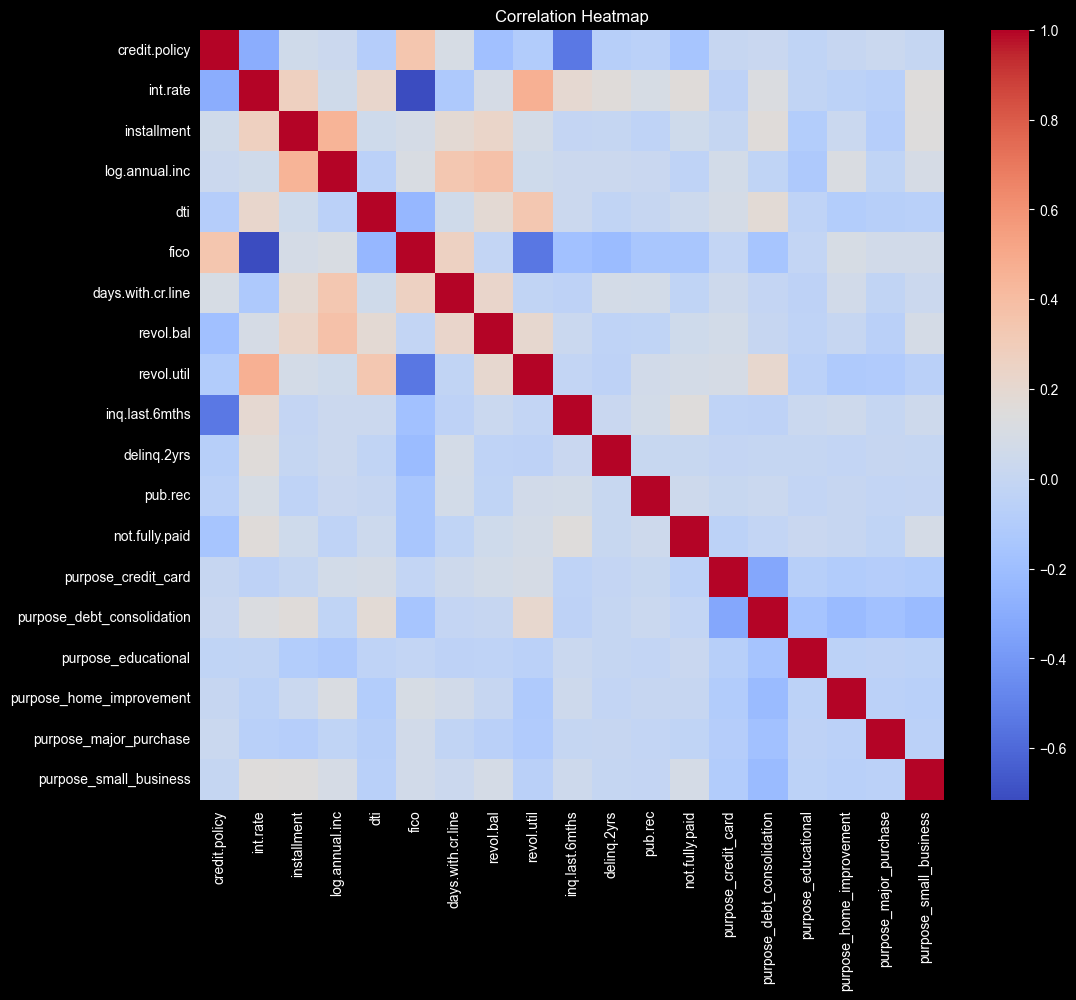

Features to drop: []


In [7]:

plt.figure(figsize=(12,10))
sns.heatmap(final_data.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Logic to identify features with correlation higher than 0.8
corr_matrix = final_data.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

print(f"Features to drop: {to_drop}")
# Drop if any found (usually empty for this dataset)
final_data.drop(to_drop, axis=1, inplace=True)

## Cell 6: Data Preprocessing (Split and Scale)

In [8]:
# Define Features and Target
X = final_data.drop('not.fully.paid', axis=1)
y = final_data['not.fully.paid']

# Split data (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

# Normalize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Cell 7: Task 4 - Modeling

### 4. Modeling
Building a Deep Learning model using Keras.

In [9]:

model = Sequential()

# Input layer & Hidden Layers
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

# Output layer (Sigmoid for binary classification)
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train,
                    epochs=25,
                    batch_size=256,
                    validation_data=(X_test, y_test),
                    verbose=1)

Epoch 1/25


C:\Users\richa\src\repos\fullstack\fs-aim-2507\assignments\unit4_deep_learning_with_tensorflow_and_keras\Unit4_CourseEndProject\LendingClubLoanDataAnalysis\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7239 - loss: 0.6038 - val_accuracy: 0.8459 - val_loss: 0.5054
Epoch 2/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8308 - loss: 0.5064 - val_accuracy: 0.8459 - val_loss: 0.4478
Epoch 3/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8341 - loss: 0.4723 - val_accuracy: 0.8459 - val_loss: 0.4272
Epoch 4/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8364 - loss: 0.4568 - val_accuracy: 0.8459 - val_loss: 0.4188
Epoch 5/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8371 - loss: 0.4436 - val_accuracy: 0.8459 - val_loss: 0.4149
Epoch 6/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8364 - loss: 0.4418 - val_accuracy: 0.8462 - val_loss: 0.4125
Epoch 7/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8376 - loss: 0.4377 - val_accuracy: 0.8462 - val_loss: 0.4102
Epoch 8/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8367 - loss: 0.4370 - val_accuracy: 0.8462 - val_loss: 0.4096
Epo

## Cell 8: Evaluation

### 5. Evaluation
Reviewing the confusion matrix and classification report.

In [11]:

predictions = (model.predict(X_test) > 0.5).astype("int32")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions, zero_division=0))

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 438us/step

Confusion Matrix:
[[2431    0]
 [ 443    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2431
           1       0.00      0.00      0.00       443

    accuracy                           0.85      2874
   macro avg       0.42      0.50      0.46      2874
weighted avg       0.72      0.85      0.78      2874

